In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../Data/data_preprocessed.csv")
df.head()

,Exercise_Frequency,Blood_Pressure,Stress_Level,Age,BMI,Heart_Rate,Sleep_Hours,Blood_Sugar_Level,Family_History,Illness,...,minor_smoking_flag,minor_alcohol_flag,gender_Male,smoking_Unknown,smoking_Yes,Medication_Use_Regular,Alcohol_Consumption_Moderate,Alcohol_Consumption_Unknown,Cholesterol_Level_High,Cholesterol_Level_Normal
0,1,2,3,90,16.6,119,3.6,143.6,0,1,...,0,0,0,0,0,0,1,0,0,0
1,1,2,1,20,29.9,69,9.9,121.8,1,0,...,0,0,0,0,1,0,0,1,0,1
2,4,3,1,52,33.5,54,8.5,107.0,1,1,...,0,0,1,0,1,0,0,0,1,0
3,4,2,1,15,20.3,72,9.5,92.1,0,1,...,1,1,1,1,0,0,0,1,1,0
4,3,3,2,60,36.0,58,4.4,113.6,0,1,...,0,0,1,0,0,0,1,0,1,0


In [3]:
x = df.drop(['Illness'], axis=1)
y = df[['Illness']]

In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Train Score: 0.7975
Test Score: 0.455
accuracy_score: 0.455


<Axes: >

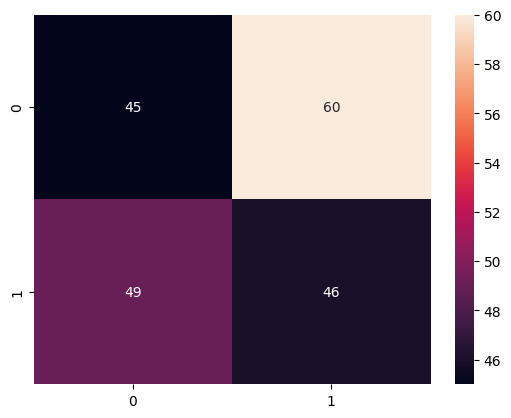

In [5]:
rf_regularized = RandomForestClassifier(
    n_estimators=100,
    max_depth=5, 
    min_samples_split=10,  
    min_samples_leaf=5,  
    max_features='sqrt',  
    random_state=42
)
rand_model = rf_regularized.fit(x_train, y_train)
print(f'Train Score: {rand_model.score(x_train, y_train)}')
print(f'Test Score: {rand_model.score(x_test, y_test)}')
rand_pred = rand_model.predict(x_test)
print(f'accuracy_score: {accuracy_score(y_test, rand_pred)}')
cm = confusion_matrix(y_test, rand_pred)
sns.heatmap(cm, annot=True)

In [6]:
std = StandardScaler()
for col in x.columns:
    x[col] = std.fit_transform(x[[col]])

In [7]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

Train Score: 0.5725
Test Score: 0.465
accuracy_score: 0.465


<Axes: >

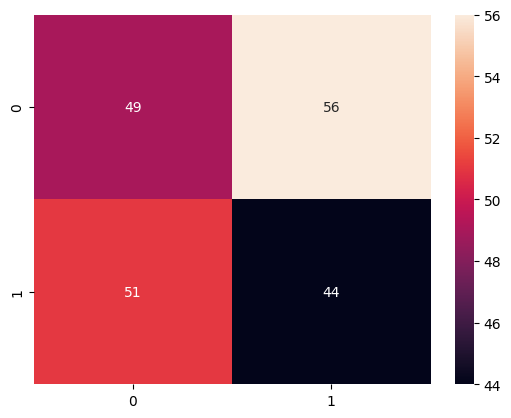

In [8]:
logi = LogisticRegression()
logi_model = logi.fit(xtrain, ytrain)
print(f'Train Score: {logi_model.score(xtrain, ytrain)}')
print(f'Test Score: {logi_model.score(xtest, ytest)}')
logi_pred = logi_model.predict(xtest)
print(f'accuracy_score: {accuracy_score(ytest, logi_pred)}')
cm = confusion_matrix(ytest, logi_pred)
sns.heatmap(cm, annot=True)

In [9]:
df.corr()['Illness'].sort_values(ascending=False)

Illness                         1.000000
alcohol_missing_flag            0.079675
Alcohol_Consumption_Unknown     0.069466
BMI                             0.046625
Heart_Rate                      0.039397
Family_History                  0.035385
Exercise_Frequency              0.027082
Cholesterol_Level_Normal        0.024243
gender_Male                     0.023014
Blood_Sugar_Level               0.021042
Blood_Pressure                  0.014320
Age                             0.012108
Sleep_Hours                     0.005211
smoking_Yes                    -0.009806
medication_missing_flag        -0.017043
minor_alcohol_flag             -0.017590
Stress_Level                   -0.028570
Cholesterol_Level_High         -0.029419
minor_smoking_flag             -0.032554
Medication_Use_Regular         -0.038495
smoking_Unknown                -0.041719
Alcohol_Consumption_Moderate   -0.062002
Name: Illness, dtype: float64